# World Population Exploration, Analysis and Trend

In this assignment, I will perform data analysis on the world's population using web scraping techniques. The dataset includes information on the populations, areas, land areas, densities, growth rates, world percentages, and rankings of hundreds of countries for multiple years.

As we progress through the notebook, we will cover topics such as setting up the scraping environment, extracting and cleaning the data, and conducting insightful analyses. my goal is to gain valuable insight into global demographics by examining trends in population.

The first thing we need to do is import the necessary libraries into the project. 

In [1]:
!pip install ipywidgets

import time
import os.path
import pandas as pd
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.support.ui import Select
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
import numpy as np
import math
import re

Next, we set up Chrome options and create a new Chrome browser instance. We use `--headless` option to run Chrome in the background.

In [2]:
chrome_options = Options()
chrome_options.add_argument("--headless")
chrome_options.add_argument("--no-sandbox")

homedir = os.path.expanduser("~")
webdriver_service = Service(f"{homedir}/chromedriver/stable/chromedriver")

browser = webdriver.Chrome(service=webdriver_service, options=chrome_options)

then, navigate to the URL of the webpage from where we want to scrape the data. 

In [3]:
browser.get("https://worldpopulationreview.com/")
browser.maximize_window()
WebDriverWait(browser, 60).until(EC.presence_of_element_located((By.TAG_NAME, "table")))

<selenium.webdriver.remote.webelement.WebElement (session="588a3dddbaf277e39eb51bdf62e9a6b5", element="28F80F87B5909157F2861D5774BB3156_element_22")>

Let's find the table containing the data that we need, And then extract all the year options from the dropdown.

here is a image of what we want to get.


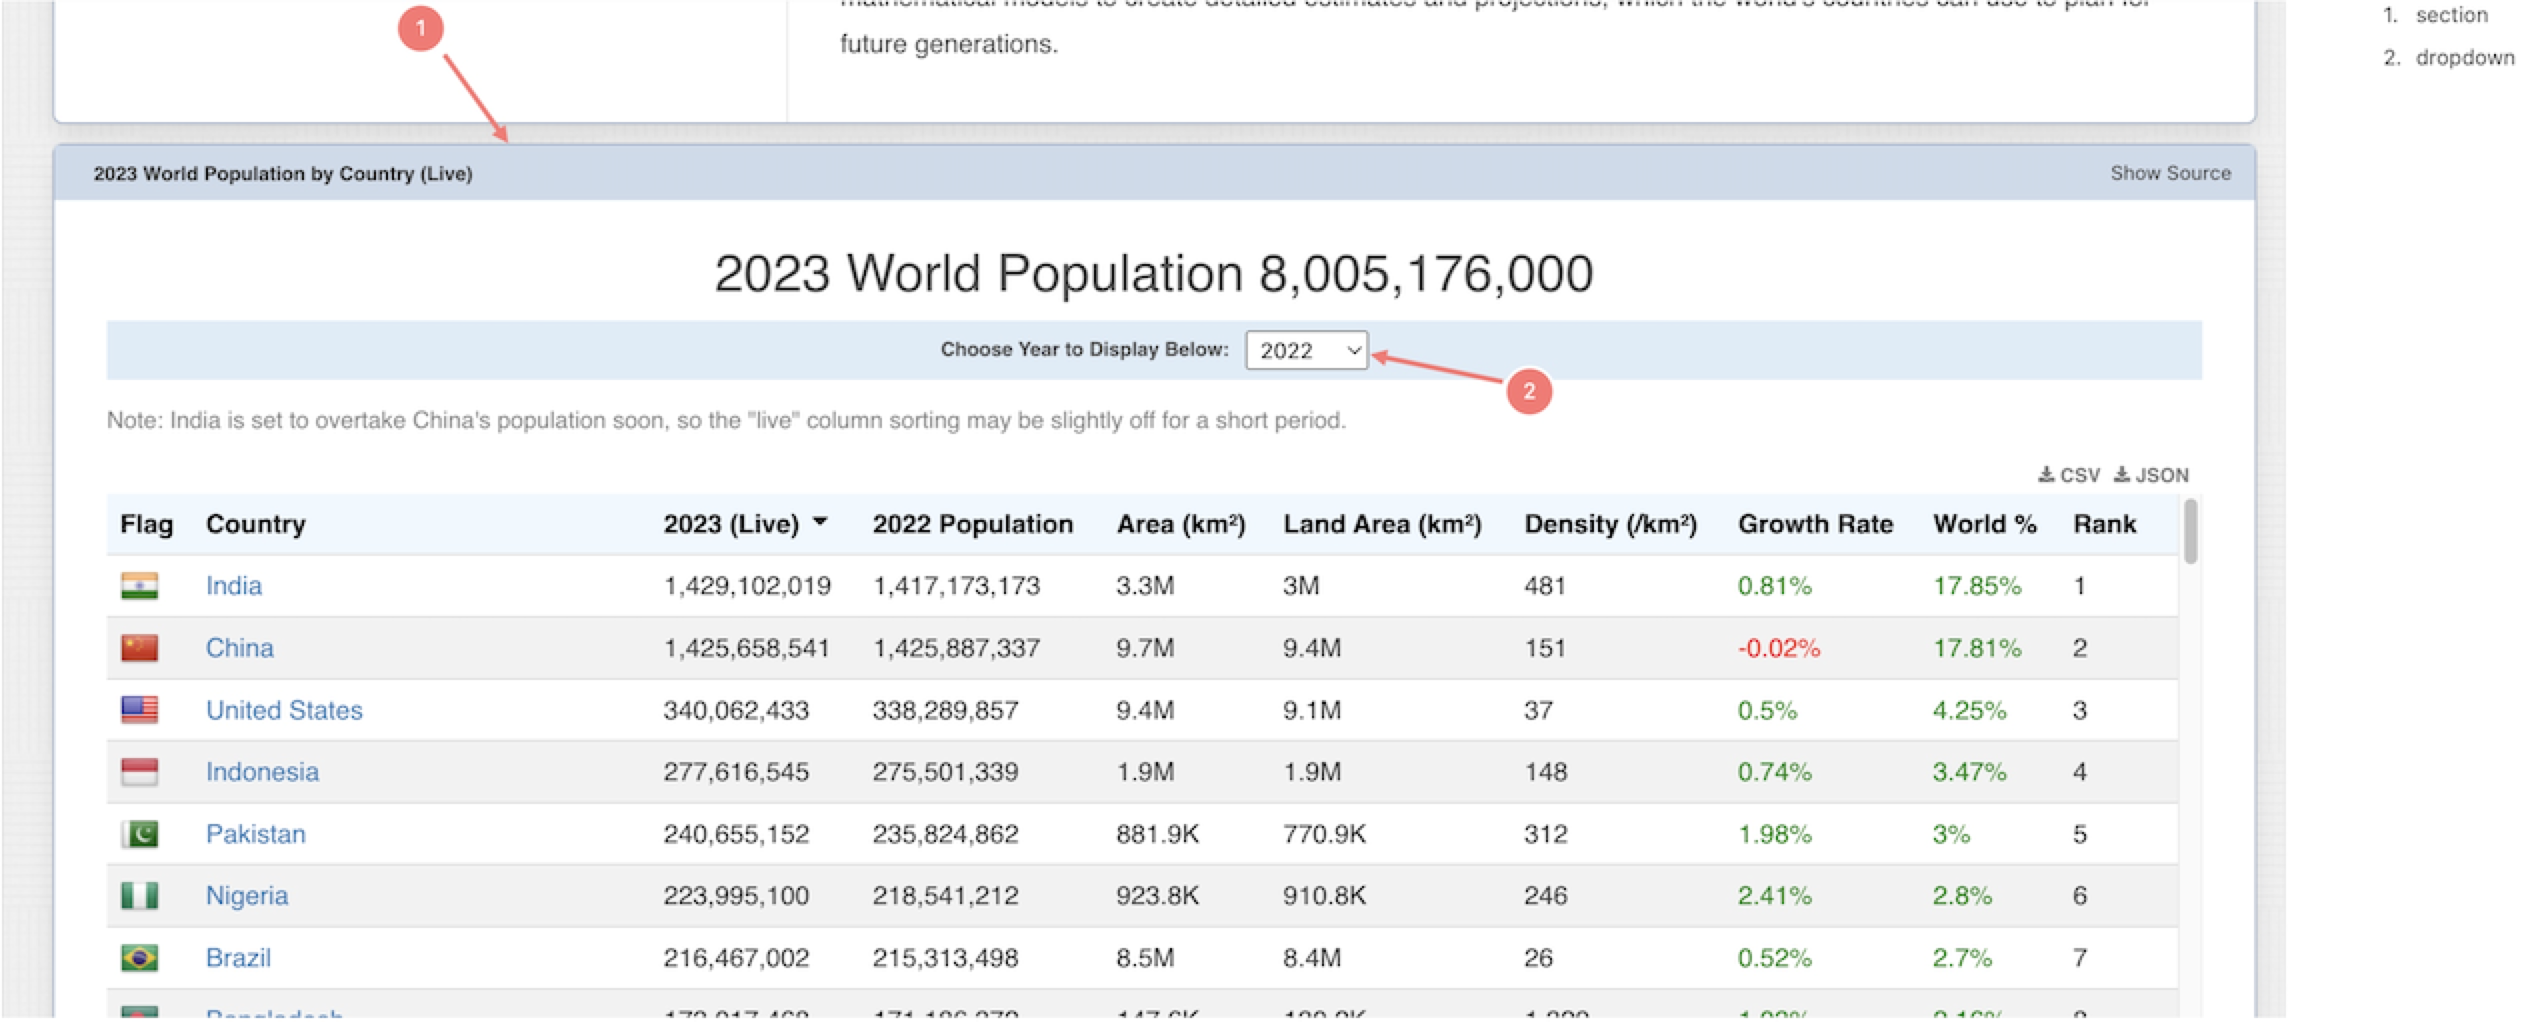

In [4]:
tables = browser.find_elements(By.TAG_NAME, "table")

# the third table is what we want
liveWorldPopulation = tables[2]

# after that’s let's found the panel that match "section.panel"
liveWorldPopulationSection = browser.find_elements(By.CSS_SELECTOR, "section.panel")[2]

# spot dropdown using XPATH
yearDropDown = Select(
    liveWorldPopulationSection.find_element(
        By.XPATH, 
        '//*[@id="__next"]/div/div[3]/section[2]/div[1]/div/div/div[2]/div[1]/select'))

years = [];

# get options in our dropdown
options = yearDropDown.options

for opt in options:
    years.append(opt.text)
    
    
print(years)

['2022', '2050', '2030', '2010', '2000', '1980']


### Reducing the data set
   Now, I have created **```get_country_data```** helpful functoin to help us finding the rows of the table, each containing data for a country. 
    We loop over all years and all countries and scrape the data. If there is an error, we catch it and continue with the next iteration of the loop. The final columns would in this following:
  
  
* **`flag_url`** (URL to an image of the country's flag)
* **`iosCode`** (IOS 2-letter code for the country)
* **`country`** (Name of the country)
* **`population`** (Population of the country)
* **`area`** (Total area of the country)
* **`landArea`** (Land area of the country)
* **`density`** (Population density of the country)
* **`growthRate`** (Population of the country growth)
* **`worldPercentage`** (Population as a percentage of the world population)
* **`rank`** (Rank of the country in terms of population)
* **`year`** (Key id for year)
* **`netChange`** (Net change in the country's population)

In [5]:
def get_country_data(country_row, year):
    td = country_row.find_elements(By.TAG_NAME, 'td')
    th = country_row.find_element(By.TAG_NAME, 'th')  
    row = [
        th.find_element(By.TAG_NAME, 'img').get_attribute('src'), # 'flag_url'
        th.find_element(By.TAG_NAME, 'img').get_attribute('alt').replace(' Flag', ''), # 'iosCode' removing the  Flag
        td[0].text, # 'country'
        td[2].text, # 'population'
        td[3].text, # 'area'
        td[4].text, # 'landArea'
        td[5].text, # 'density'
        td[6].text, # 'growthRate'
        td[7].text, # 'worldPercentage'
        td[8].text, # 'rank'
        year # 'year'
    ]
    return row

now, find the rows of the table

In [6]:
# spot (the XPATH) which contains a list of countries
countriesByYear = liveWorldPopulationSection.find_elements(By.XPATH,'//*[@id="__next"]/div/div[3]/section[2]/div[1]/div/div/div[2]/div[3]/div[2]/table/tbody/tr')


data = []

# each year from availabile years
try:
    for year in years:
        for country in countriesByYear: 
               row = get_country_data(country, year)
               data.append(row)
except Exception as e:
    print(f"Error Screpping Data {e}")

We then close the browser session and convert the scraped data into a Pandas DataFrame. 

In [7]:
browser.quit()

columns = [
    'flag_url','iosCode', 'country', 'population', 'area', 
    'landArea', 'density', 'growthRate', 'worldPercentage', 'rank', 'year']


df = pd.DataFrame(data, columns=columns)

Now, let's save the results. to use it later.

In [8]:

df.to_csv('data/world_population_data_scraped.csv', index=False)

scraping now done. Let's load our saved cleaned data 

In [9]:
df =  pd.read_csv('data/world_population_data_scraped.csv');

In [10]:
df

,flag_url,iosCode,country,population,area,landArea,density,growthRate,worldPercentage,rank,year
0,https://s3.amazonaws.com/images.wpr.com/flags/...,IN,India,"1,417,173,173",3.3M,3M,481,0.81%,17.85%,1,2022
1,https://s3.amazonaws.com/images.wpr.com/flags/...,CN,China,"1,425,887,337",9.7M,9.4M,151,-0.02%,17.81%,2,2022
2,https://s3.amazonaws.com/images.wpr.com/flags/...,US,United States,"338,289,857",9.4M,9.1M,37,0.5%,4.25%,3,2022
3,https://s3.amazonaws.com/images.wpr.com/flags/...,ID,Indonesia,"275,501,339",1.9M,1.9M,148,0.74%,3.47%,4,2022
4,https://s3.amazonaws.com/images.wpr.com/flags/...,PK,Pakistan,"235,824,862",881.9K,770.9K,312,1.98%,3%,5,2022
...,...,...,...,...,...,...,...,...,...,...,...
1399,https://s3.amazonaws.com/images.wpr.com/flags/...,MS,Montserrat,"4,390",102,102,43,-0.09%,NaN,230,1980
1400,https://s3.amazonaws.com/images.wpr.com/flags/...,FK,Falkland Islands,"3,780",12.2K,12.2K,0.31,0.29%,NaN,231,1980
1401,https://s3.amazonaws.com/images.wpr.com/flags/...,NU,Niue,"1,934",261,261,7,0.05%,NaN,232,1980
1402,https://s3.amazonaws.com/images.wpr.com/flags/...,TK,Tokelau,"1,871",12,10,189,1.18%,NaN,233,1980


### Normalizing Data
Looking at the fields, it seems that the date is not in their proper `datetype`. for **consistency** and integrity of our **data quality**. let's do **normalization to our data and data Enhancements**. I have created a helpful functions that will help use to do so, 
* **`validate_fields`** (Validates if the data type of a column matches the expected type)
* **`convert_scale`** (convert scaled values from string to float)
* **`convert_percentage`** (handle missing percentages)
* **`convert_netChange`** (handle missing netChange)

In [11]:
def validate_fields(df, column, expected_type):
    if df[column].dtype == expected_type:
        print(f" {column} successful for {expected_type}")
    else:
        print(f"{column} failed for {expected_type}")


def convert_scale(value):
    if 'M' in value:
        return float(value.replace('M', '')) * 10**6
    elif 'K' in value:
        return float(value.replace('K', '')) * 10**3
    elif '< 1' in value:
        return 0.5
    else:
        return float(value)

    
def convert_percentage(value):
    try:
        if pd.isnull(value) or value == '':
            return -1.0  # Assign -1 if missing or empty string (I'm making it -1 to have differnces between real data who has 0)
        else:
            return float(value)
    except ValueError:
        return -1.0  # Assign -1 if the value cannot be converted to float (I'm making it -1 to have differnces between real data who has 0)


    
def convert_netChange(value):
    if np.isnan(value):
        return 0.0 
    else:
        return float(value)

let's defines a dictionary, `conversion_map`. This dictionary will be used as a guide for cleaning and converting our data. Each `key-value` pair in the dictionary corresponds to a column in our data and how to process it. 

Each key is the column name and each value is a tuple with three elements:

- The desired data type for that column
- Any unwanted characters that need to be removed from that column
- Any functions that need to be applied to that column.

In [12]:
def normalise():
    # Conversion map
    conversion_map = {
        'population': (float, ',', ''),
        'area': (float, None, convert_scale),
        'landArea': (float, None, convert_scale),
        'density': (float, ',', None),
        'growthRate': (float, '%', None),
        'worldPercentage': (float, 0, convert_percentage),
        'rank': (int, ',', '')
    }

    for col, (dtype, remove, function) in conversion_map.items():
        try:
            if df[col].dtype == 'object':
                if remove:
                    df[col] = df[col].str.replace(remove, '')

                if function:
                    df[col] = df[col].apply(function)
                else:
                    df[col] = df[col].astype(dtype)

            else:
                df[col] = df[col].astype(dtype)

            validate_fields(df, col, dtype)
        except Exception as e:
            print(f"Issue {col}: {e}")

            
    try:
        df['year'] = df['year'].astype(int)
        validate_fields(df, 'year', int)
    except Exception as e:
        print(f"Issue in year: {e}")

    try:
        df['netChange'] = df['netChange'].apply(convert_netChange)
        validate_fields(df, 'netChange', float)
    except Exception as e:
        print(f"Issue in netChange: {e}")


    df.to_csv('data/world_population.csv', index=False)

# Fixing Data And Add Addoantal
 After exploring the scraped data it appears that some columns do not have consistent values. 

 As an example, on the website, the `area` ..etc. column is presented as a string prefixed with `M` which stands for million and `K` This was considered in my cleanup, where I used the **`convert_scale`** function to handle the scale. This is due to the lack of consistency in the value where the data will not be accurate. Data will likely be available to download as a CSV file on the website it's the same data but more accurately. As a result, in order to fix one of the most valuable aspects of data analysts' consistency. 
 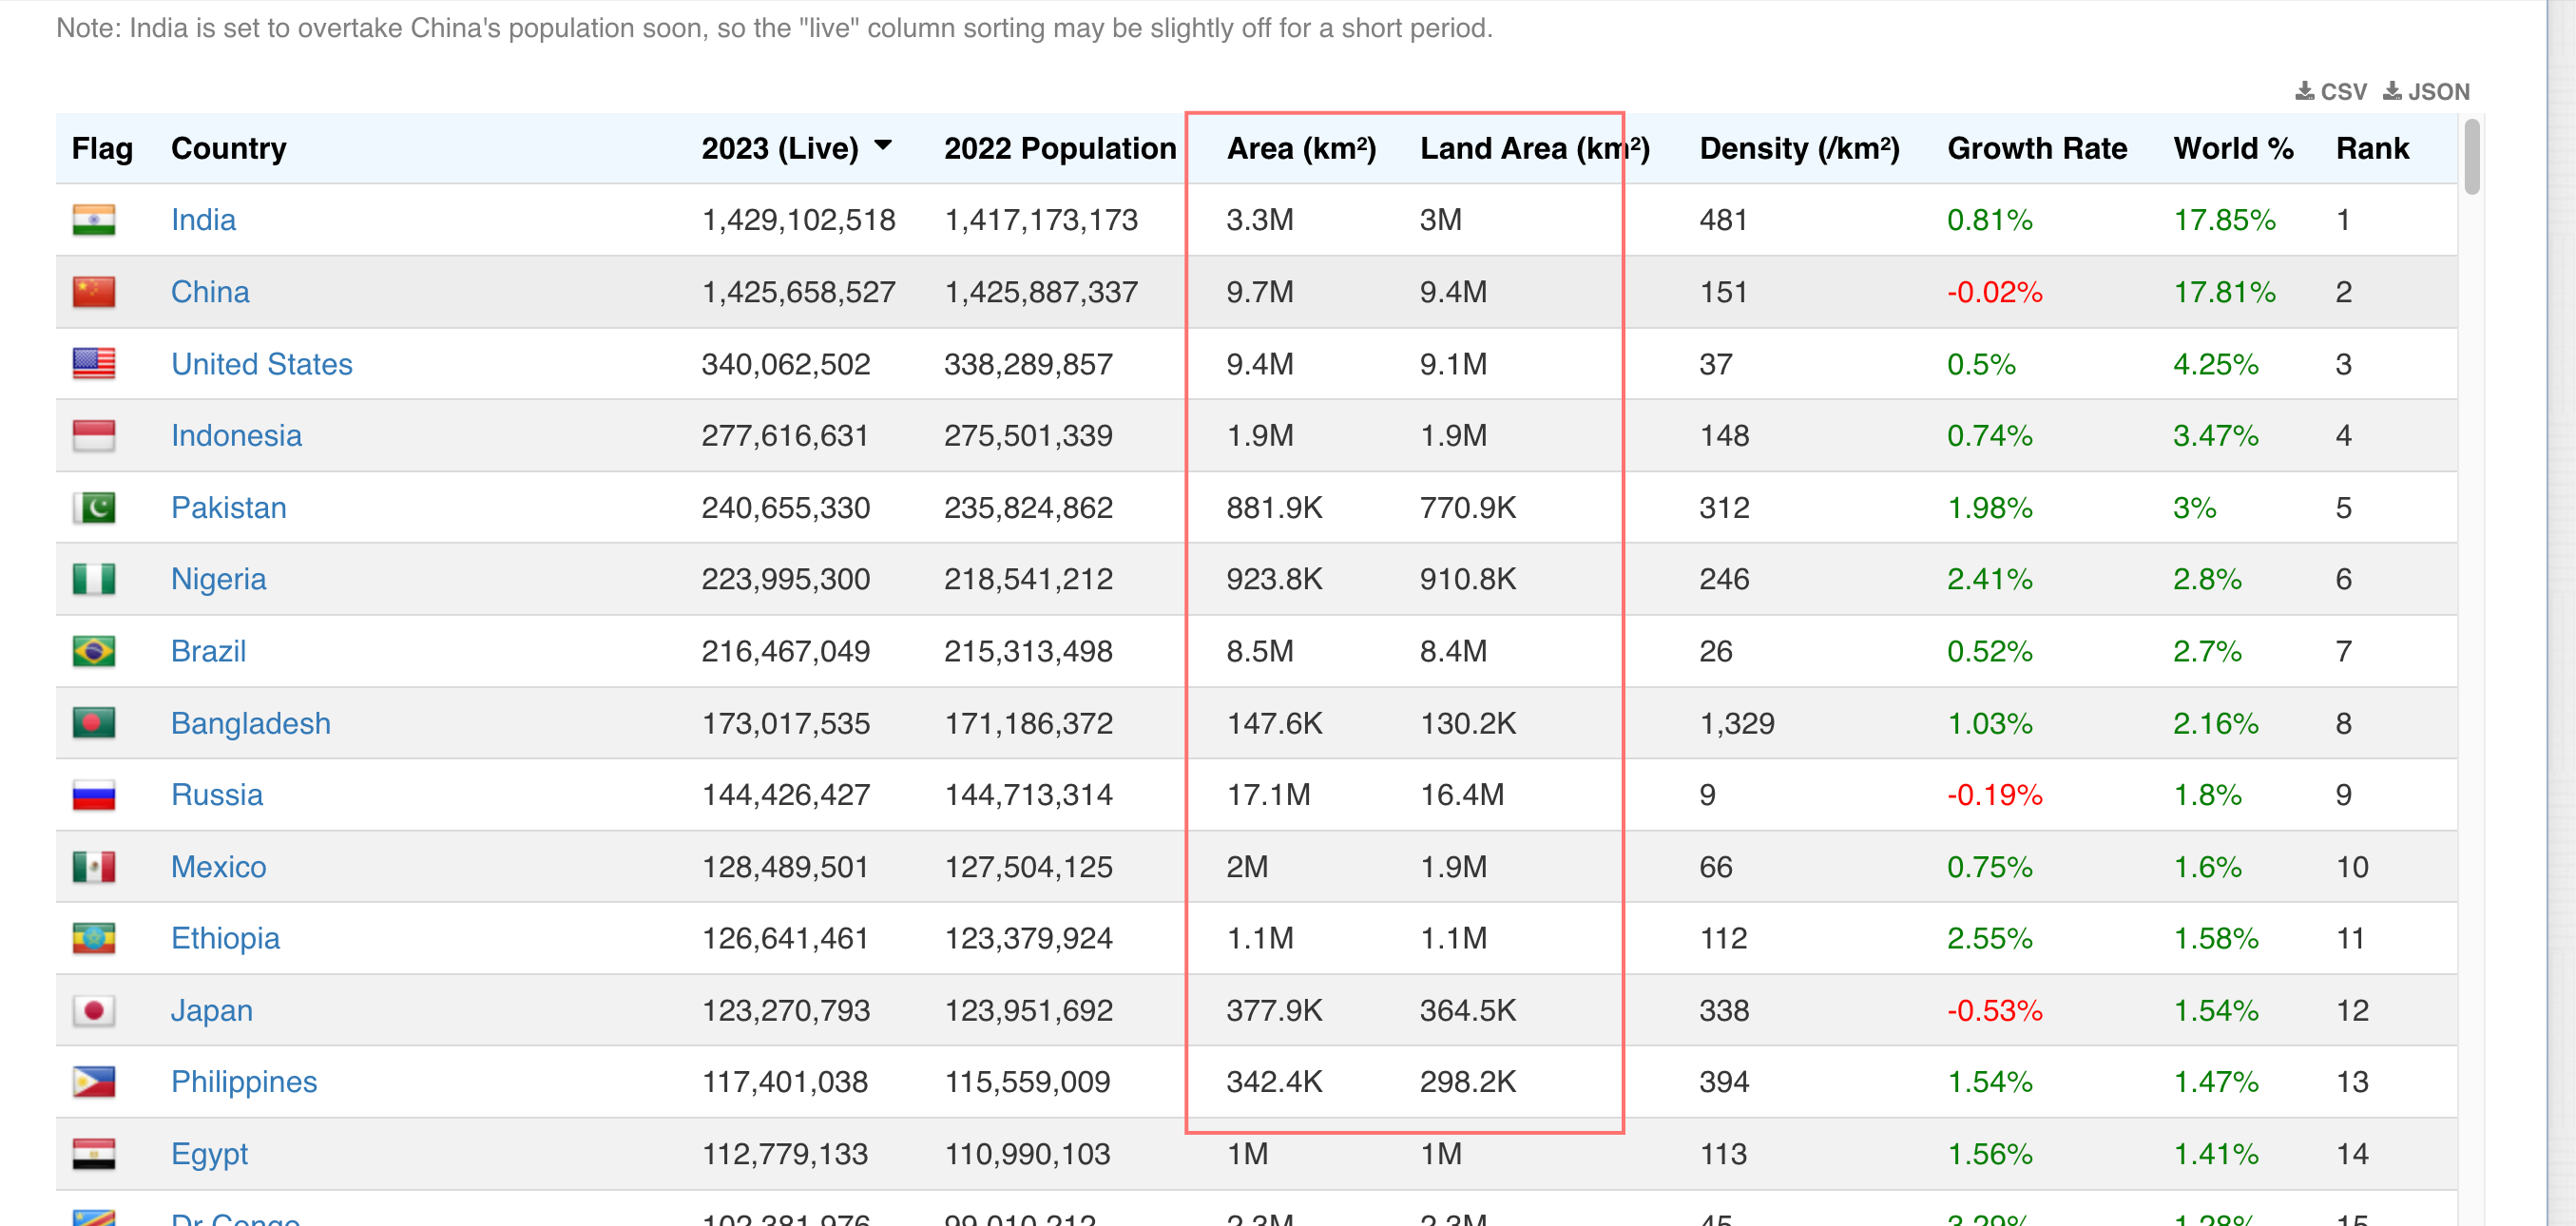
 
 you can download the file from within the website 
 
 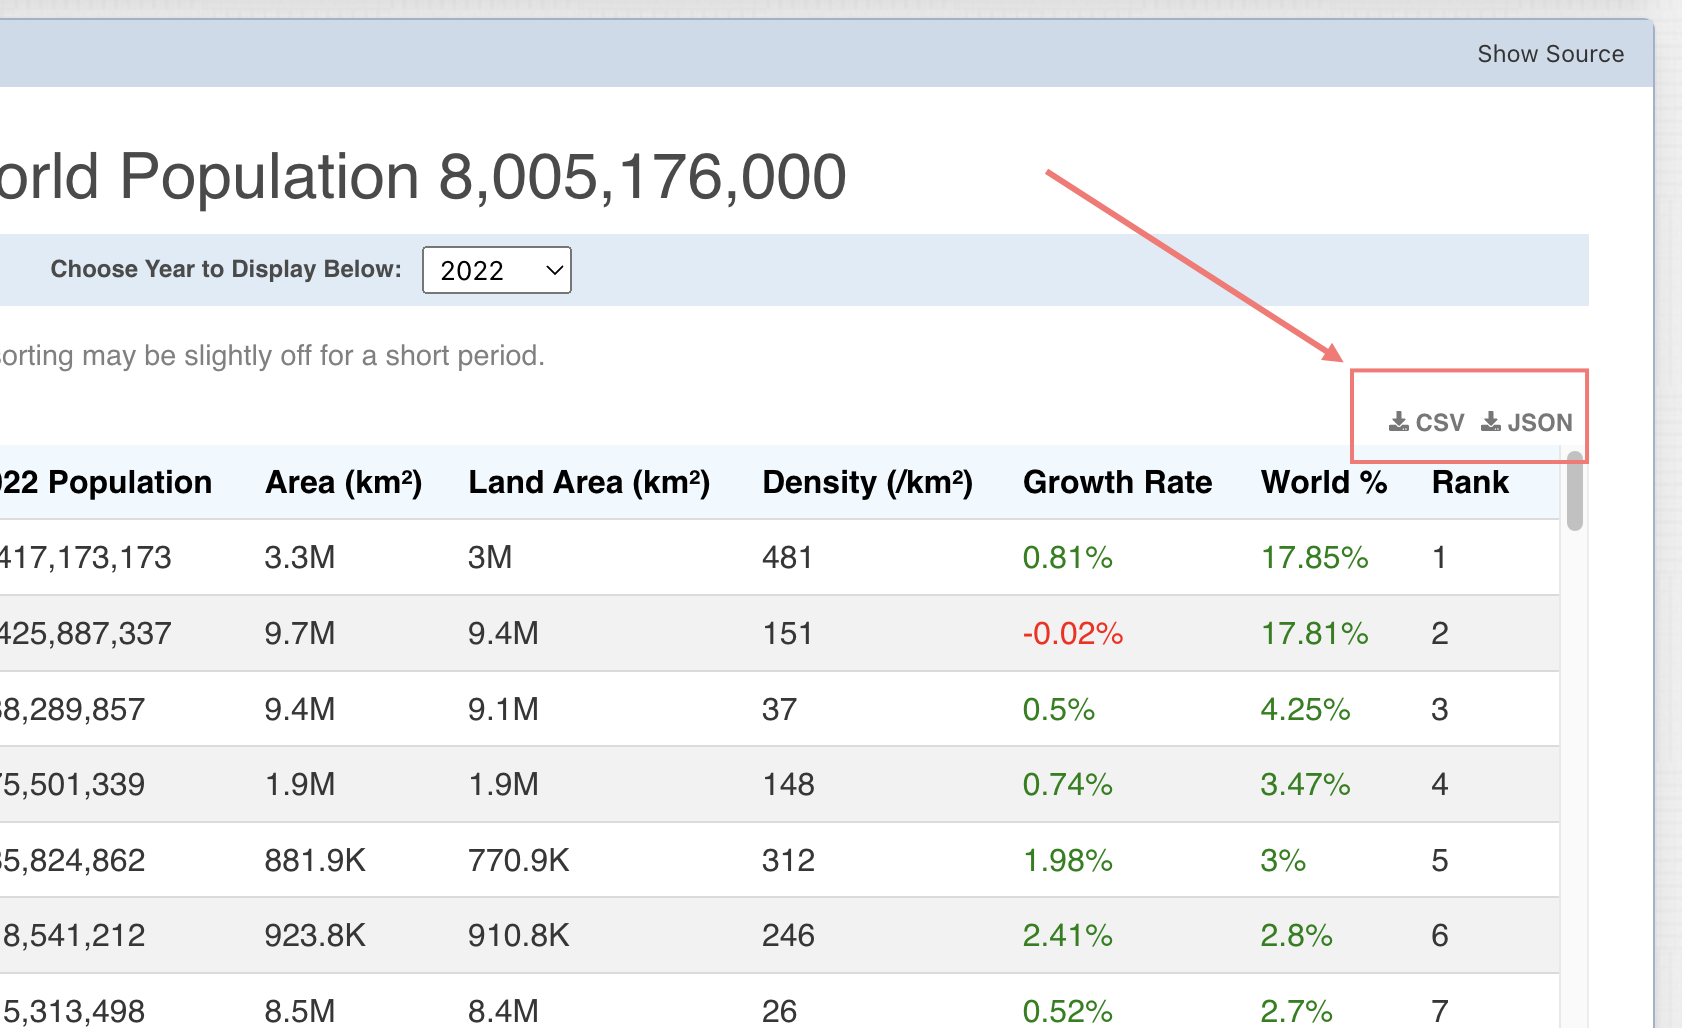
 
 
 
 > **NOTE** the downloaded file can be found in **data/countries-table.csv** path

 creating a copy of the original dataframe `df`.
 then, I'm loading data from a CSV file named `data/countries-table.csv` we have download `df_new`.

In [13]:
# Load the new data
df_new = pd.read_csv('data/countries-table.csv')

My solution uses the `melt` function. There will be two columns for `year` and for `population` in the value_vars table. The columns specified in id_vars remain unchanged. 

In [14]:

# Extract year from the columns and melt the dataframe
df_new = df_new.melt(id_vars=["country", "cca2", "rank", "worldPercentage", "growthRate", "density", 'area', 'landAreaKm', 'netChange'], 
                     value_vars=["pop1980", "pop2000", "pop2010", "pop2022", "pop2023", "pop2030", "pop2050"], 
                     var_name='year', 
                     value_name='population')


 extracts the year number from the `year` column (which is of the format 'popXXXX') and converts it to integer.

To match the original dataframe, the `rename` function is used to rename **`cca2`** and **`landAreaKm`** to **`iosCode`** and **`landArea`** respectively.

In [15]:
df_new['year'] = df_new['year'].apply(lambda x: int(re.findall('\d+', x)[0]))

df_new.rename(columns={'cca2': 'iosCode', 'landAreaKm': 'landArea'}, inplace=True)

df['country'] = df['country'].str.lower()
df_new['country'] = df_new['country'].str.lower()

df.set_index(['year', 'country', 'iosCode'], inplace=True)
df_new.set_index(['year', 'country', 'iosCode'], inplace=True)

Using the `update` function, we update `df`s columns `population`, `landArea`, `growthRate`, `worldPercentage`, and `density` with values from `df_new`. In which case will give us the **`consistency`** we are seeking in our dataset

In [16]:
df['population'].update(df_new['population'])
df['landArea'].update(df_new['landArea'])
df['area'].update(df_new['area'])
df['growthRate'].update(df_new['growthRate'])
df['worldPercentage'].update(df_new['worldPercentage'])
df['density'].update(df_new['density'])

df.reset_index(inplace=True)
df_new.reset_index(inplace=True)

if 'netChange' in df.columns:
    df = df.drop('netChange', axis=1)
    

if 'netChange' in df_new.columns:
    df = pd.merge(df, df_new[['year', 'country', 'iosCode', 'netChange']], 
                       on=['year', 'country', 'iosCode'], how='left', suffixes=('_y', '_x'))

cols_to_update = ['rank', 'worldPercentage', 'growthRate', 'density', 'area', 'landArea', 'population']

    
# Drop the temporary columns
if 'netChange_y' in df.columns:
    df.drop(columns=['netChange_y'], inplace=True)
    
if 'netChange_x' in df.columns:
    df.drop(columns=['netChange_x'], inplace=True)


df.to_csv('data/world_population.csv', index=False)

## let's reload our data
  here we will do some clean up and fix the data types
  after we marged and ensure our data is most accured than the scrpped one.

In [17]:
df =  pd.read_csv('data/world_population.csv');
# re fix any corrupted data 
normalise()

 population successful for <class 'float'>
 area successful for <class 'float'>
 landArea successful for <class 'float'>
 density successful for <class 'float'>
 growthRate successful for <class 'float'>
 worldPercentage successful for <class 'float'>
 rank successful for <class 'int'>
 year successful for <class 'int'>
 netChange successful for <class 'float'>


   #### Inspect the Data

In [18]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1404 entries, 0 to 1403
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   year             1404 non-null   int64  
 1   country          1404 non-null   object 
 2   iosCode          1398 non-null   object 
 3   flag_url         1404 non-null   object 
 4   population       1404 non-null   float64
 5   area             1404 non-null   float64
 6   landArea         1404 non-null   float64
 7   density          1404 non-null   float64
 8   growthRate       1404 non-null   float64
 9   worldPercentage  1404 non-null   float64
 10  rank             1404 non-null   int64  
 11  netChange        1404 non-null   float64
dtypes: float64(7), int64(2), object(3)
memory usage: 131.8+ KB


,year,population,area,landArea,density,growthRate,worldPercentage,rank,netChange
count,1404.000000,1.404000e+03,1.404000e+03,1.404000e+03,1404.000000,1404.000000,1404.000000,1404.000000,1404.000000
mean,2015.333333,3.119703e+07,5.814500e+05,5.571123e+05,451.283962,0.024925,-0.029896,117.500000,0.009945
std,22.269009,1.260517e+08,1.758698e+06,1.686957e+06,1975.833038,0.168103,0.183385,67.573434,0.034164
min,1980.000000,5.100000e+02,4.400000e-01,4.400000e-01,0.138000,-0.074500,-1.000000,1.000000,-0.028600
25%,2000.000000,3.746520e+05,2.586000e+03,2.574500e+03,39.256500,0.002300,0.000000,59.000000,0.000000
50%,2016.000000,4.976214e+06,8.119950e+04,7.568925e+04,97.481000,0.008200,0.000700,117.500000,0.000550
75%,2030.000000,1.961762e+07,4.383170e+05,4.072835e+05,243.144300,0.017400,0.002900,176.000000,0.007200
max,2050.000000,1.670491e+09,1.709824e+07,1.637687e+07,21402.705200,2.150000,0.178500,234.000000,0.418400


##  Data Analysis

  I will try and answers those questions. 
  
       - What is the total world population by year?
       - How has the total population of the world evolved over time?
       - What is the distribution of population by countries in a specific year?
       - What is the total world population for each year?
       - What are the top 5 most populated countries in a specific year?

#### 1. What is the total world population by year?

In [19]:
import matplotlib.pyplot as plt

df['population'] = df['population'].astype(float).astype(int)

world_population_by_year = df.groupby('year')['population'].sum()
print(world_population_by_year)

year
1980    4444373548
2000    6148393356
2010    6984576155
2022    7973413043
2030    8543884565
2050    9705983941
Name: population, dtype: int64


### 2. How has the total population of the world evolved over time?

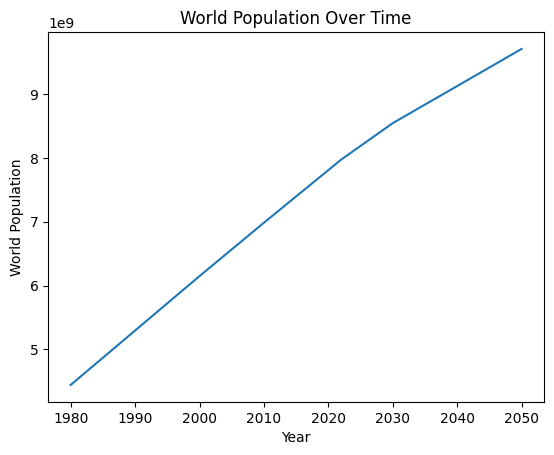

In [20]:
world_population_by_year.plot(kind='line')
plt.xlabel('Year')
plt.ylabel('World Population')
plt.title('World Population Over Time')
plt.show()

### 3. What is the distribution of population by countries in a specific year?

country
China            1264099069
India            1059633675
United States     282398554
Indonesia         214072421
Brazil            175873720
Pakistan          154369924
Russia            146844839
Bangladesh        129193327
Japan             126803861
Nigeria           122851984
Name: population, dtype: int64


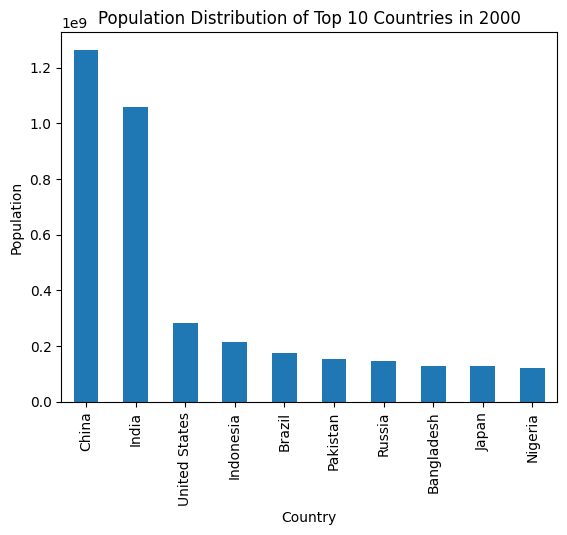

In [21]:
year = 2000
df['country'] = df['country'].str.title()
populationByCountry = df[df['year'] == year].set_index('country')['population']

topCountries = 10 
populationTopCountries = populationByCountry.nlargest(topCountries)

print(populationTopCountries)

populationTopCountries.sort_values(ascending=False).plot(kind='bar')
plt.xlabel('Country')
plt.ylabel('Population')
plt.title('Population Distribution of Top {} Countries in {}'.format(topCountries, year))
plt.show()


we can see how our data is baing vasluation based on the data given, 
 here a start vuaslatoin 3 countries to see the population growth across the years we are fetch 

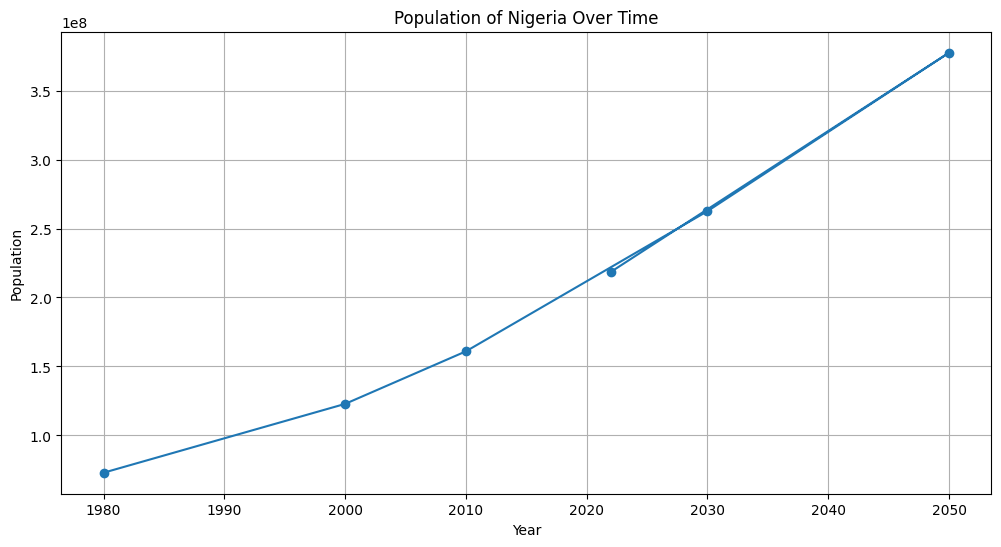

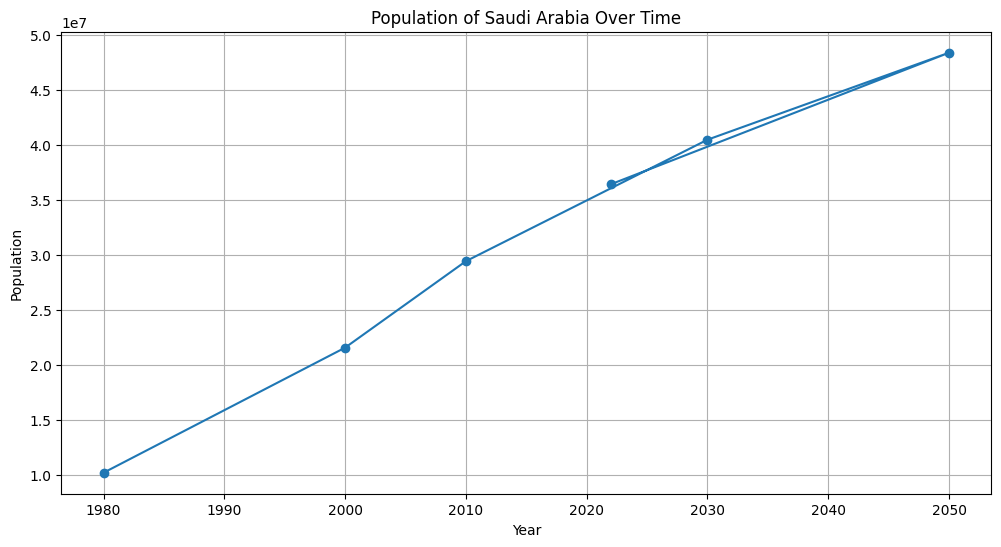

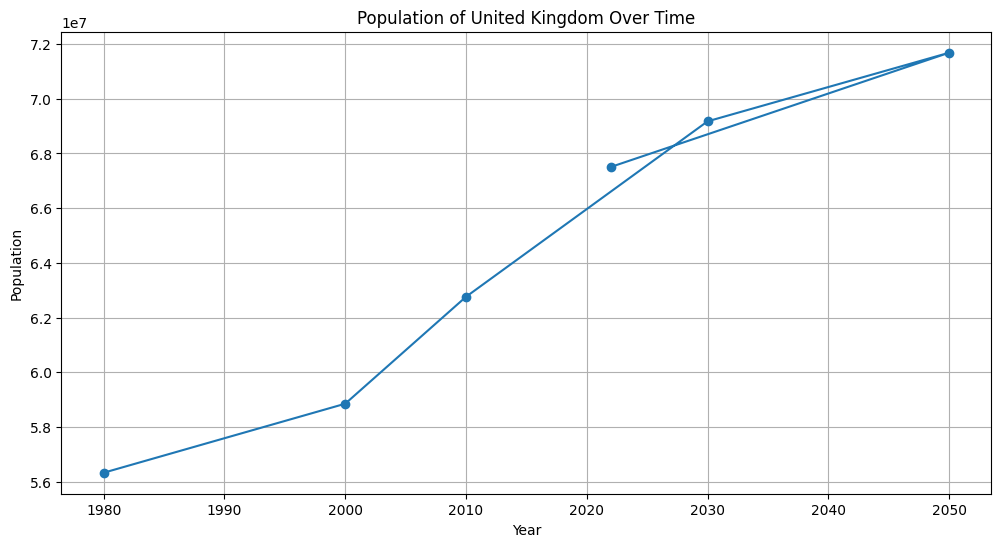

In [22]:
def population_of_country(country):
    country_data = df[df['country'] == country]
    plt.figure(figsize=(12, 6))
    plt.plot(country_data['year'], country_data['population'], marker='o')
    plt.xlabel('Year')
    plt.ylabel('Population')
    plt.title('Population of {} Over Time'.format(country))
    plt.grid(True)
    plt.show()

    
population_of_country('Nigeria') 
population_of_country('Saudi Arabia')
population_of_country('United Kingdom')

### 4. What is the total world population for each year?


In [23]:
worldPopulationByYear = df.groupby('year')['population'].sum()

worldPopulationByYear

year
1980    4444373548
2000    6148393356
2010    6984576155
2022    7973413043
2030    8543884565
2050    9705983941
Name: population, dtype: int64

### What are the top 5 most populated countries in a specific year?

In [24]:
year = 2022
topCountries = df[df['year'] == year].nlargest(5, 'population')[['country', 'population']]

topCountries

,country,population
1,China,1425887337
0,India,1417173173
2,United States,338289857
3,Indonesia,275501339
4,Pakistan,235824862


## References


<a name="datahub"></a>[1]: https://worldpopulationreview.com/

<a name="datahub"></a>[2]: https://www.kaggle.com/datasets/iamsouravbanerjee/world-population-dataset
